In [10]:
# =============================================================================
# 导入必要的库
# =============================================================================
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Conv2D, Flatten, Concatenate, Dropout
from tensorflow.keras.optimizers import Adam
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import random
from collections import deque
from copy import deepcopy
import time
import pickle
import os

# 设置随机种子
tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

# =============================================================================
# 核心类定义
# =============================================================================

class Box:
    """优化的箱子类"""
    def __init__(self, length, width, height, box_type=0):
        self.length = length
        self.width = width
        self.height = height
        self.rotation = 0  # 0=原始, 1=Y轴旋转90度
        self.box_type = box_type  # 箱子类型标识
        self._volume = length * width * height  # 缓存体积计算
        
    def rotate_y(self):
        """Y轴旋转90度"""
        rotated = Box(self.width, self.length, self.height, self.box_type)
        rotated.rotation = 1
        return rotated
        
    def volume(self):
        return self._volume
        
    def get_rotations(self):
        """返回所有可能的旋转状态"""
        return [self, self.rotate_y()]

class FastBinPackingEnv:
    """高效的强化学习装箱环境"""
    def __init__(self, container_size, box_groups, max_actions_per_box=200, grid_resolution=1):
        self.container_length, self.container_width, self.container_height = container_size
        self.box_groups = box_groups
        self.max_actions_per_box = max_actions_per_box
        self.grid_resolution = grid_resolution  # 网格分辨率
        
        # 优化的网格系统
        self.grid_length = self.container_length // grid_resolution
        self.grid_width = self.container_width // grid_resolution
        
        # 2D高度图表示3D空间 - 添加通道维度
        self.height_map = np.zeros((self.grid_length, self.grid_width, 1), dtype=np.float32)
        
        # 已放置的箱子记录
        self.placed_boxes = []
        
        # 按体积降序排列所有箱子
        self.all_boxes = self._create_sorted_boxes()
        self.remaining_boxes = self.all_boxes.copy()
        self.current_box_idx = 0
        
        # 候选点缓存
        self.candidate_points_cache = []
        self.cache_valid = False
        
    def _create_sorted_boxes(self):
        """创建按体积降序排列的箱子列表"""
        boxes = []
        for i, (box_type, count) in enumerate(self.box_groups):
            boxes.extend([Box(*box_type, box_type=i) for _ in range(count)])
        return sorted(boxes, key=lambda x: x.volume(), reverse=True)
    
    def reset(self):
        """重置环境"""
        self.height_map = np.zeros((self.grid_length, self.grid_width, 1), dtype=np.float32)
        self.placed_boxes = []
        self.remaining_boxes = self.all_boxes.copy()
        self.current_box_idx = 0
        self.candidate_points_cache = []
        self.cache_valid = False
        return self.get_state()
    
    def get_state(self):
        """获取当前状态"""
        if self.current_box_idx >= len(self.remaining_boxes):
            current_box_features = [0, 0, 0, 0]  # 无箱子
        else:
            box = self.remaining_boxes[self.current_box_idx]
            # 归一化箱子尺寸
            current_box_features = [
                box.length / self.container_length,
                box.width / self.container_width, 
                box.height / self.container_height,
                box.box_type / len(self.box_groups)
            ]
        
        # 归一化高度图
        normalized_height_map = self.height_map / (self.container_height / self.grid_resolution)
        
        # 其他特征
        remaining_count = len(self.remaining_boxes) - self.current_box_idx
        volume_utilization = self.get_volume_utilization()
        total_boxes = len(self.all_boxes)
        progress = self.current_box_idx / total_boxes if total_boxes > 0 else 1.0
        
        return {
            'height_map': normalized_height_map,
            'current_box': np.array(current_box_features, dtype=np.float32),
            'meta': np.array([remaining_count / total_boxes, volume_utilization, progress], dtype=np.float32)
        }
    
    def get_candidate_points(self):
        """获取候选放置点（启发式优化）"""
        if self.cache_valid and self.candidate_points_cache:
            return self.candidate_points_cache
            
        candidates = set()
        
        # 始终包含原点
        candidates.add((0, 0))
        
        # 添加现有箱子的边界点
        for box in self.placed_boxes[-10:]:  # 只考虑最近的10个箱子
            x_grid = box['x'] // self.grid_resolution
            y_grid = box['y'] // self.grid_resolution
            length_grid = box['length'] // self.grid_resolution
            width_grid = box['width'] // self.grid_resolution
            
            # 添加四个角点
            candidates.update([
                (x_grid + length_grid, y_grid),
                (x_grid, y_grid + width_grid),
                (x_grid + length_grid, y_grid + width_grid),
                (x_grid, y_grid)
            ])
        
        # 添加网格边界点
        if len(self.placed_boxes) < 5:  # 初期多考虑边界
            for i in range(0, self.grid_length, max(1, self.grid_length // 10)):
                for j in range(0, self.grid_width, max(1, self.grid_width // 10)):
                    candidates.add((i, j))
        
        # 过滤有效候选点
        valid_candidates = []
        for x, y in candidates:
            if 0 <= x < self.grid_length and 0 <= y < self.grid_width:
                valid_candidates.append((x, y))
        
        # 按高度排序，优先选择低位置
        valid_candidates.sort(key=lambda p: self.height_map[p[0], p[1], 0])
        
        self.candidate_points_cache = valid_candidates[:self.max_actions_per_box // 2]
        self.cache_valid = True
        
        return self.candidate_points_cache
    
    def get_valid_actions(self):
        """获取当前状态下的有效动作（优化版）"""
        if self.current_box_idx >= len(self.remaining_boxes):
            return []
        
        valid_actions = []
        current_box = self.remaining_boxes[self.current_box_idx]
        candidate_points = self.get_candidate_points()
        
        # 尝试两种旋转状态
        for rotation in [0, 1]:
            box = current_box if rotation == 0 else current_box.rotate_y()
            
            for x_grid, y_grid in candidate_points:
                # 转换为实际坐标
                x = x_grid * self.grid_resolution
                y = y_grid * self.grid_resolution
                
                if self.can_place_box(box, x, y):
                    # 简化的动作编码
                    action_id = x_grid * self.grid_width * 2 + y_grid * 2 + rotation
                    valid_actions.append(action_id)
                    
                    if len(valid_actions) >= self.max_actions_per_box:
                        break
            
            if len(valid_actions) >= self.max_actions_per_box:
                break
        
        return valid_actions
    
    def can_place_box(self, box, x, y):
        """检查是否可以在(x,y)位置放置箱子"""
        # 边界检查
        if x + box.length > self.container_length:
            return False
        if y + box.width > self.container_width:
            return False
        
        # 网格坐标转换
        x_start = x // self.grid_resolution
        y_start = y // self.grid_resolution
        x_end = min((x + box.length) // self.grid_resolution + 1, self.grid_length)
        y_end = min((y + box.width) // self.grid_resolution + 1, self.grid_width)
        
        if x_start >= self.grid_length or y_start >= self.grid_width:
            return False
        
        # 高度检查 - 修复维度问题
        region = self.height_map[x_start:x_end, y_start:y_end, 0]
        if region.size == 0:
            return False
            
        max_height = np.max(region) * self.grid_resolution
        
        if max_height + box.height > self.container_height:
            return False
        
        return True
    
    def step(self, action_id):
        """执行动作"""
        if self.current_box_idx >= len(self.remaining_boxes):
            return self.get_state(), 0, True, {'placed_count': len(self.placed_boxes)}
        
        # 解码动作
        x_grid = action_id // (self.grid_width * 2)
        remaining = action_id % (self.grid_width * 2)
        y_grid = remaining // 2
        rotation = remaining % 2
        
        # 转换为实际坐标
        x = x_grid * self.grid_resolution
        y = y_grid * self.grid_resolution
        
        current_box = self.remaining_boxes[self.current_box_idx]
        box = current_box if rotation == 0 else current_box.rotate_y()
        
        # 尝试放置箱子
        success = False
        if self.can_place_box(box, x, y):
            self.place_box(box, x, y)
            reward = self.calculate_reward(box, x, y, True)
            success = True
            self.cache_valid = False  # 状态改变，缓存失效
        else:
            # 无效动作的惩罚
            reward = -1.0
        
        self.current_box_idx += 1
        
        # 检查是否结束
        done = self.current_box_idx >= len(self.remaining_boxes)
        
        # 终局奖励
        if done:
            utilization = self.get_volume_utilization()
            placed_ratio = len(self.placed_boxes) / len(self.all_boxes)
            reward += utilization * 50 + placed_ratio * 30
        
        next_state = self.get_state()
        info = {
            'placed_count': len(self.placed_boxes),
            'success': success,
            'utilization': self.get_volume_utilization()
        }
        
        return next_state, reward, done, info
    
    def place_box(self, box, x, y):
        """在(x,y)位置放置箱子"""
        # 网格坐标转换
        x_start = x // self.grid_resolution
        y_start = y // self.grid_resolution
        x_end = min((x + box.length) // self.grid_resolution + 1, self.grid_length)
        y_end = min((y + box.width) // self.grid_resolution + 1, self.grid_width)
        
        # 获取放置高度 - 修复维度问题
        region = self.height_map[x_start:x_end, y_start:y_end, 0]
        z = np.max(region) * self.grid_resolution if region.size > 0 else 0
        
        # 更新高度图
        new_height_grid = (z + box.height) / self.grid_resolution
        self.height_map[x_start:x_end, y_start:y_end, 0] = new_height_grid
        
        # 记录放置信息
        placed_box = {
            'box_id': len(self.placed_boxes),
            'x': x, 'y': y, 'z': z,
            'length': box.length, 'width': box.width, 'height': box.height,
            'rotation': box.rotation,
            'box_type': box.box_type
        }
        self.placed_boxes.append(placed_box)
    
    def calculate_reward(self, box, x, y, success):
        """优化的奖励函数"""
        if not success:
            return -1.0
        
        # 基础体积奖励（归一化）
        container_volume = self.container_length * self.container_width * self.container_height
        volume_reward = (box.volume() / container_volume) * 10
        
        # 网格坐标
        x_start = x // self.grid_resolution
        y_start = y // self.grid_resolution
        x_end = min((x + box.length) // self.grid_resolution + 1, self.grid_length)
        y_end = min((y + box.width) // self.grid_resolution + 1, self.grid_width)
        
        # 高度相关奖励 - 修复维度问题
        region = self.height_map[x_start:x_end, y_start:y_end, 0]
        avg_height = np.mean(region) * self.grid_resolution
        height_penalty = -avg_height / self.container_height * 2
        
        # 边角奖励
        edge_bonus = 0
        if x == 0: edge_bonus += 0.5
        if y == 0: edge_bonus += 0.5
        if x + box.length == self.container_length: edge_bonus += 0.5
        if y + box.width == self.container_width: edge_bonus += 0.5
        
        # 紧密度奖励
        support_ratio = np.sum(region > 0) / region.size if region.size > 0 else 0
        support_reward = support_ratio * 1.5
        
        # 平整度奖励 - 修复维度问题
        height_variance = np.var(self.height_map[:, :, 0])
        flatness_reward = -height_variance * 0.1
        
        total_reward = volume_reward + height_penalty + edge_bonus + support_reward + flatness_reward
        return np.clip(total_reward, -10, 10)  # 限制奖励范围
    
    def get_volume_utilization(self):
        """计算体积利用率"""
        if not self.placed_boxes:
            return 0.0
        
        total_placed_volume = sum(box['length'] * box['width'] * box['height'] 
                                 for box in self.placed_boxes)
        container_volume = self.container_length * self.container_width * self.container_height
        
        return total_placed_volume / container_volume
    
    def save_results(self, filename="rl_packing_result.csv"):
        """保存结果到CSV"""
        if not self.placed_boxes:
            print("没有放置任何箱子")
            return
        
        df = pd.DataFrame(self.placed_boxes)
        df.to_csv(filename, index=False)
        print(f"结果已保存到 {filename}")
        print(f"装箱数量: {len(self.placed_boxes)}")
        print(f"体积利用率: {self.get_volume_utilization():.2%}")
        return len(self.placed_boxes), self.get_volume_utilization()
    
    def visualize_3d(self, title="3D装箱结果"):
        """3D可视化"""
        if not self.placed_boxes:
            print("没有箱子可以可视化")
            return
            
        fig = plt.figure(figsize=(15, 10))
        ax = fig.add_subplot(111, projection='3d')
        
        # 绘制集装箱边框
        self.draw_container_wireframe(ax)
        
        # 为不同类型的箱子使用不同颜色
        colors = plt.cm.Set3(np.linspace(0, 1, len(self.box_groups)))
        
        # 绘制每个箱子
        for box in self.placed_boxes:
            color = colors[box['box_type']]
            self.draw_box(ax, box, color)
        
        ax.set_xlabel('Length (mm)')
        ax.set_ylabel('Width (mm)') 
        ax.set_zlabel('Height (mm)')
        ax.set_title(f'{title} - 利用率: {self.get_volume_utilization():.2%} - 装箱数: {len(self.placed_boxes)}')
        
        plt.tight_layout()
        plt.show()
    
    def draw_container_wireframe(self, ax):
        """绘制集装箱边框"""
        x = [0, self.container_length]
        y = [0, self.container_width]
        z = [0, self.container_height]
        
        # 绘制边框
        for xi in x:
            for yi in y:
                ax.plot([xi, xi], [yi, yi], z, 'k-', alpha=0.6, linewidth=2)
        for xi in x:
            for zi in z:
                ax.plot([xi, xi], y, [zi, zi], 'k-', alpha=0.6, linewidth=2)
        for yi in y:
            for zi in z:
                ax.plot(x, [yi, yi], [zi, zi], 'k-', alpha=0.6, linewidth=2)
    
    def draw_box(self, ax, box, color='blue'):
        """绘制单个箱子"""
        x, y, z = box['x'], box['y'], box['z']
        dx, dy, dz = box['length'], box['width'], box['height']
        
        # 创建立方体的顶点
        vertices = np.array([
            [x, y, z], [x+dx, y, z], [x+dx, y+dy, z], [x, y+dy, z],  # 底面
            [x, y, z+dz], [x+dx, y, z+dz], [x+dx, y+dy, z+dz], [x, y+dy, z+dz]  # 顶面
        ])
        
        # 定义立方体的面
        faces = [
            [vertices[0], vertices[1], vertices[2], vertices[3]],  # 底面
            [vertices[4], vertices[5], vertices[6], vertices[7]],  # 顶面
            [vertices[0], vertices[1], vertices[5], vertices[4]],  # 前面
            [vertices[2], vertices[3], vertices[7], vertices[6]],  # 后面
            [vertices[1], vertices[2], vertices[6], vertices[5]],  # 右面
            [vertices[4], vertices[7], vertices[3], vertices[0]]   # 左面
        ]
        
        # 绘制每个面
        for face in faces:
            face = np.array(face)
            ax.plot_trisurf(face[:, 0], face[:, 1], face[:, 2], color=color, alpha=0.7)

# =============================================================================
# DQN算法实现
# =============================================================================

class DQNAgent:
    """DQN智能体"""
    def __init__(self, state_shape, action_size, learning_rate=0.001):
        self.state_shape = state_shape
        self.action_size = action_size
        self.memory = deque(maxlen=10000)
        self.epsilon = 1.0  # 探索率
        self.epsilon_min = 0.01
        self.epsilon_decay = 0.995
        self.learning_rate = learning_rate
        self.batch_size = 32
        self.target_update_freq = 100  # 目标网络更新频率
        self.update_counter = 0
        
        # 构建神经网络
        self.q_network = self._build_model()
        self.target_network = self._build_model()
        self.update_target_network()
        
    def _build_model(self):
        """构建DQN神经网络"""
        # 高度图输入
        height_input = Input(shape=self.state_shape['height_map'], name='height_map')
        
        # 卷积层处理高度图
        conv1 = Conv2D(32, (3, 3), activation='relu', padding='same')(height_input)
        conv2 = Conv2D(64, (3, 3), activation='relu', padding='same')(conv1)
        conv3 = Conv2D(64, (3, 3), activation='relu', padding='same')(conv2)
        height_flat = Flatten()(conv3)
        
        # 箱子特征输入
        box_input = Input(shape=self.state_shape['current_box'], name='current_box')
        box_dense = Dense(64, activation='relu')(box_input)
        box_dense = Dense(32, activation='relu')(box_dense)
        
        # 元信息输入
        meta_input = Input(shape=self.state_shape['meta'], name='meta')
        meta_dense = Dense(32, activation='relu')(meta_input)
        
        # 融合所有特征
        concat = Concatenate()([height_flat, box_dense, meta_dense])
        
        # 全连接层
        dense1 = Dense(512, activation='relu')(concat)
        dense1 = Dropout(0.3)(dense1)
        dense2 = Dense(256, activation='relu')(dense1)
        dense2 = Dropout(0.3)(dense2)
        dense3 = Dense(128, activation='relu')(dense2)
        
        # 输出层
        output = Dense(self.action_size, activation='linear')(dense3)
        
        # 创建模型
        model = Model(inputs=[height_input, box_input, meta_input], outputs=output)
        model.compile(optimizer=Adam(learning_rate=self.learning_rate), loss='mse')
        
        return model
    
    def update_target_network(self):
        """更新目标网络"""
        self.target_network.set_weights(self.q_network.get_weights())
    
    def remember(self, state, action, reward, next_state, done):
        """存储经验"""
        self.memory.append((state, action, reward, next_state, done))
    
    def act(self, state, valid_actions):
        """选择动作"""
        if len(valid_actions) == 0:
            return 0
        
        if np.random.random() <= self.epsilon:
            return random.choice(valid_actions)
        
        # 预测Q值
        q_values = self.q_network.predict([
            state['height_map'].reshape(1, *state['height_map'].shape),
            state['current_box'].reshape(1, -1),
            state['meta'].reshape(1, -1)
        ], verbose=0)[0]
        
        # 只考虑有效动作
        valid_q_values = [(action, q_values[action]) for action in valid_actions if action < len(q_values)]
        if not valid_q_values:
            return random.choice(valid_actions)
        
        # 选择Q值最大的有效动作
        best_action = max(valid_q_values, key=lambda x: x[1])[0]
        return best_action
    
    def replay(self):
        """经验回放训练"""
        if len(self.memory) < self.batch_size:
            return
        
        batch = random.sample(self.memory, self.batch_size)
        
        # 准备训练数据
        height_maps = []
        current_boxes = []
        metas = []
        targets = []
        
        for state, action, reward, next_state, done in batch:
            height_maps.append(state['height_map'])
            current_boxes.append(state['current_box'])
            metas.append(state['meta'])
            
            # 计算目标Q值
            target = reward
            if not done:
                next_q_values = self.target_network.predict([
                    next_state['height_map'].reshape(1, *next_state['height_map'].shape),
                    next_state['current_box'].reshape(1, -1),
                    next_state['meta'].reshape(1, -1)
                ], verbose=0)[0]
                target += 0.95 * np.max(next_q_values)  # gamma = 0.95
            
            # 获取当前Q值
            current_q_values = self.q_network.predict([
                state['height_map'].reshape(1, *state['height_map'].shape),
                state['current_box'].reshape(1, -1),
                state['meta'].reshape(1, -1)
            ], verbose=0)[0]
            
            current_q_values[action] = target
            targets.append(current_q_values)
        
        # 转换为numpy数组
        height_maps = np.array(height_maps)
        current_boxes = np.array(current_boxes)
        metas = np.array(metas)
        targets = np.array(targets)
        
        # 训练网络
        self.q_network.fit([height_maps, current_boxes, metas], targets, 
                          epochs=1, verbose=0, batch_size=self.batch_size)
        
        # 更新探索率
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay
        
        # 定期更新目标网络
        self.update_counter += 1
        if self.update_counter % self.target_update_freq == 0:
            self.update_target_network()
    
    def save_model(self, filepath):
        """保存模型"""
        self.q_network.save(filepath)
        
    def load_model(self, filepath):
        """加载模型"""
        self.q_network = tf.keras.models.load_model(filepath)
        self.update_target_network()

# =============================================================================
# 训练系统
# =============================================================================

class BinPackingTrainer:
    """装箱训练器"""
    def __init__(self, container_size, box_groups, model_save_path="models/"):
        self.container_size = container_size
        self.box_groups = box_groups
        self.model_save_path = model_save_path
        
        # 创建模型保存目录
        os.makedirs(model_save_path, exist_ok=True)
        
        # 对于大型容器自动使用更大的网格分辨率
        grid_resolution = 100 if max(container_size) > 10000 else 1
        max_actions = 50 if grid_resolution > 1 else 200
        
        # 创建环境
        self.env = FastBinPackingEnv(container_size, box_groups, 
                                   max_actions_per_box=max_actions,
                                   grid_resolution=grid_resolution)
        
        # 获取状态和动作空间信息
        state = self.env.reset()
        self.state_shape = {
            'height_map': state['height_map'].shape,
            'current_box': state['current_box'].shape,
            'meta': state['meta'].shape
        }
        
        # 动作空间大小（估算）
        max_actions = self.env.grid_length * self.env.grid_width * 2
        self.action_size = max_actions
        
        # 创建DQN智能体
        self.agent = DQNAgent(self.state_shape, self.action_size)
        
        # 训练统计
        self.training_stats = {
            'episodes': [],
            'rewards': [],
            'utilizations': [],
            'placed_counts': [],
            'episode_times': []
        }
    
    def train(self, episodes=1000, save_interval=100, verbose=True):
        """训练智能体"""
        best_utilization = 0
        best_placed_count = 0
        
        for episode in range(episodes):
            start_time = time.time()
            
            state = self.env.reset()
            total_reward = 0
            steps = 0
            
            while True:
                # 获取有效动作
                valid_actions = self.env.get_valid_actions()
                if not valid_actions:
                    break
                
                # 选择动作
                action = self.agent.act(state, valid_actions)
                
                # 执行动作
                next_state, reward, done, info = self.env.step(action)
                
                # 存储经验
                self.agent.remember(state, action, reward, next_state, done)
                
                state = next_state
                total_reward += reward
                steps += 1
                
                if done:
                    break
            
            # 经验回放
            self.agent.replay()
            
            # 记录统计信息
            episode_time = time.time() - start_time
            utilization = self.env.get_volume_utilization()
            placed_count = len(self.env.placed_boxes)
            
            self.training_stats['episodes'].append(episode)
            self.training_stats['rewards'].append(total_reward)
            self.training_stats['utilizations'].append(utilization)
            self.training_stats['placed_counts'].append(placed_count)
            self.training_stats['episode_times'].append(episode_time)
            
            # 更新最佳记录
            if utilization > best_utilization:
                best_utilization = utilization
                best_placed_count = placed_count
                # 保存最佳模型
                self.agent.save_model(f"{self.model_save_path}/best_model.h5")
            
            # 定期保存和输出
            if episode % save_interval == 0:
                self.agent.save_model(f"{self.model_save_path}/model_episode_{episode}.h5")
                
                if verbose:
                    avg_reward = np.mean(self.training_stats['rewards'][-save_interval:])
                    avg_utilization = np.mean(self.training_stats['utilizations'][-save_interval:])
                    avg_placed = np.mean(self.training_stats['placed_counts'][-save_interval:])
                    
                    print(f"Episode {episode:4d} | "
                          f"Reward: {total_reward:6.2f} | "
                          f"Utilization: {utilization:.2%} | "
                          f"Placed: {placed_count:2d} | "
                          f"Epsilon: {self.agent.epsilon:.3f} | "
                          f"Time: {episode_time:.2f}s")
                    print(f"Last {save_interval} episodes avg - "
                          f"Reward: {avg_reward:6.2f} | "
                          f"Utilization: {avg_utilization:.2%} | "
                          f"Placed: {avg_placed:.1f}")
                    print(f"Best so far - Utilization: {best_utilization:.2%} | "
                          f"Placed: {best_placed_count}")
                    print("-" * 80)
        
        print(f"\n训练完成!")
        print(f"最佳体积利用率: {best_utilization:.2%}")
        print(f"最佳装箱数量: {best_placed_count}")
        
        return self.training_stats
    
    def evaluate(self, episodes=10, model_path=None):
        """评估智能体性能"""
        if model_path:
            self.agent.load_model(model_path)
        
        # 设置为评估模式（不探索）
        original_epsilon = self.agent.epsilon
        self.agent.epsilon = 0
        
        results = []
        
        for episode in range(episodes):
            state = self.env.reset()
            total_reward = 0
            
            while True:
                valid_actions = self.env.get_valid_actions()
                if not valid_actions:
                    break
                
                action = self.agent.act(state, valid_actions)
                next_state, reward, done, info = self.env.step(action)
                
                state = next_state
                total_reward += reward
                
                if done:
                    break
            
            utilization = self.env.get_volume_utilization()
            placed_count = len(self.env.placed_boxes)
            
            results.append({
                'episode': episode,
                'reward': total_reward,
                'utilization': utilization,
                'placed_count': placed_count
            })
            
            print(f"评估 Episode {episode+1}: "
                  f"利用率 {utilization:.2%}, "
                  f"装箱数 {placed_count}, "
                  f"奖励 {total_reward:.2f}")
        
        # 恢复探索率
        self.agent.epsilon = original_epsilon
        
        # 计算平均性能
        avg_utilization = np.mean([r['utilization'] for r in results])
        avg_placed = np.mean([r['placed_count'] for r in results])
        avg_reward = np.mean([r['reward'] for r in results])
        
        print(f"\n评估结果:")
        print(f"平均体积利用率: {avg_utilization:.2%}")
        print(f"平均装箱数量: {avg_placed:.1f}")
        print(f"平均奖励: {avg_reward:.2f}")
        
        return results
    
    def plot_training_stats(self):
        """绘制训练统计图"""
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        
        # 奖励曲线
        axes[0, 0].plot(self.training_stats['episodes'], self.training_stats['rewards'])
        axes[0, 0].set_title('Training Rewards')
        axes[0, 0].set_xlabel('Episode')
        axes[0, 0].set_ylabel('Total Reward')
        axes[0, 0].grid(True)
        
        # 体积利用率曲线
        axes[0, 1].plot(self.training_stats['episodes'], 
                       [u * 100 for u in self.training_stats['utilizations']])
        axes[0, 1].set_title('Volume Utilization')
        axes[0, 1].set_xlabel('Episode')
        axes[0, 1].set_ylabel('Utilization (%)')
        axes[0, 1].grid(True)
        
        # 装箱数量曲线
        axes[1, 0].plot(self.training_stats['episodes'], self.training_stats['placed_counts'])
        axes[1, 0].set_title('Placed Boxes Count')
        axes[1, 0].set_xlabel('Episode')
        axes[1, 0].set_ylabel('Count')
        axes[1, 0].grid(True)
        
        # 每轮训练时间
        axes[1, 1].plot(self.training_stats['episodes'], self.training_stats['episode_times'])
        axes[1, 1].set_title('Episode Training Time')
        axes[1, 1].set_xlabel('Episode')
        axes[1, 1].set_ylabel('Time (seconds)')
        axes[1, 1].grid(True)
        
        plt.tight_layout()
        plt.show()
    
    def save_training_stats(self, filepath="training_stats.pkl"):
        """保存训练统计数据"""
        with open(filepath, 'wb') as f:
            pickle.dump(self.training_stats, f)
    
    def load_training_stats(self, filepath="training_stats.pkl"):
        """加载训练统计数据"""
        with open(filepath, 'rb') as f:
            self.training_stats = pickle.load(f)

# =============================================================================
# 主程序和测试
# =============================================================================

def test_environment():
    """测试环境"""
    print("=" * 50)
    print("测试环境")
    print("=" * 50)
    
    # 定义容器和箱子
    container_size = (120, 100, 100)  # 容器尺寸
    box_groups = [
        ((17, 10, 12), 20),  # 17x10x12的箱子，20个
        ((10, 8, 9), 15),    # 10x8x9的箱子，15个
        ((15, 12, 8), 10),   # 15x12x8的箱子，10个
    ]
    
    # 创建环境
    env = FastBinPackingEnv(container_size, box_groups, max_actions_per_box=100)
    
    # 重置环境
    state = env.reset()
    print(f"初始状态:")
    print(f"高度图形状: {state['height_map'].shape}")
    print(f"当前箱子: {state['current_box']}")
    print(f"元信息: {state['meta']}")
    print(f"总箱子数: {len(env.all_boxes)}")
    
    # 获取有效动作
    start_time = time.time()
    valid_actions = env.get_valid_actions()
    action_time = time.time() - start_time
    print(f"有效动作数量: {len(valid_actions)} (耗时: {action_time:.4f}s)")
    
    # 随机放置几个箱子进行测试
    total_time = 0
    for i in range(min(10, len(valid_actions))):
        start_time = time.time()
        action = random.choice(valid_actions)
        next_state, reward, done, info = env.step(action)
        step_time = time.time() - start_time
        total_time += step_time
        
        print(f"步骤 {i+1}: 动作={action}, 奖励={reward:.2f}, "
              f"成功={info['success']}, 完成={done}, 耗时={step_time:.4f}s")
        
        if done:
            break
        
        valid_actions = env.get_valid_actions()
        if not valid_actions:
            print("没有更多有效动作")
            break
    
    print(f"平均步骤耗时: {total_time/(i+1):.4f}s")
    
    # 保存结果
    placed_count, utilization = env.save_results("test_result.csv")
    
    # 可视化（如果有箱子被放置）
    if env.placed_boxes:
        env.visualize_3d("环境测试结果")


In [ ]:

def train_model():
    """训练模型"""
    print("=" * 50)
    print("开始训练DQN模型")
    print("=" * 50)
    
    # 定义实际问题规模
    container_size = (1200, 235, 269)  # 40' High Cube集装箱
    box_groups = [
        ((120, 80, 90), 200),   # 类型1: 120x80x90mm, 200个
        ((100, 60, 80), 150),   # 类型2: 100x60x80mm, 150个
        ((80, 60, 70), 100),    # 类型3: 80x60x70mm, 100个
        ((150, 100, 120), 80),  # 类型4: 150x100x120mm, 80个
    ]
    
    # 创建训练器
    trainer = BinPackingTrainer(container_size, box_groups)
    
    print(f"容器尺寸: {container_size}")
    print(f"箱子类型: {len(box_groups)}")
    print(f"总箱子数: {sum(count for _, count in box_groups)}")
    print(f"状态空间: {trainer.state_shape}")
    print(f"动作空间: {trainer.action_size}")
    print()
    
    # 开始训练
    start_time = time.time()
    stats = trainer.train(episodes=500, save_interval=50)
    training_time = time.time() - start_time
    
    print(f"总训练时间: {training_time:.2f}秒 ({training_time/60:.2f}分钟)")
    
    # 绘制训练统计
    trainer.plot_training_stats()
    
    # 保存训练统计
    trainer.save_training_stats()
    
    # 评估最佳模型
    print("\n评估最佳模型:")
    eval_results = trainer.evaluate(episodes=5, model_path="models/best_model.h5")
    
    # 可视化最后一次评估结果
    trainer.env.visualize_3d("最终训练结果")

def industrial_demo():
    """工业级演示"""
    print("=" * 50)
    print("工业级3D装箱演示")
    print("=" * 50)
    
    # 40英尺高立方集装箱标准尺寸
    container_size = (12032, 2352, 2698)  # cm
    
    # 实际产品尺寸示例 - 减少数量以加快演示
    box_groups = [
        ((600, 400, 300), 30),     # 大型产品
        ((400, 300, 200), 50),     # 中型产品
        ((300, 200, 150), 80),     # 小型产品
        ((800, 600, 400), 20),     # 超大型产品
    ]
    
    print(f"集装箱尺寸: {container_size[0]}x{container_size[1]}x{container_size[2]} mm")
    print(f"集装箱体积: {container_size[0]*container_size[1]*container_size[2]/1e9:.2f} 立方米")
    
    total_boxes = sum(count for _, count in box_groups)
    total_box_volume = sum(l*w*h*count for (l,w,h), count in box_groups)
    theoretical_utilization = total_box_volume / (container_size[0]*container_size[1]*container_size[2])
    
    print(f"总箱子数: {total_boxes}")
    print(f"箱子总体积: {total_box_volume/1e9:.2f} 立方米")
    print(f"理论最大利用率: {theoretical_utilization:.2%}")
    print()
    
    # 创建并训练模型
    trainer = BinPackingTrainer(container_size, box_groups)
    
    print(f"网格分辨率: {trainer.env.grid_resolution}mm")
    print(f"网格尺寸: {trainer.env.grid_length}x{trainer.env.grid_width}")
    print(f"状态空间: {trainer.state_shape}")
    print()
    
    # 快速训练演示
    print("开始快速训练演示...")
    start_time = time.time()
    stats = trainer.train(episodes=50, save_interval=10, verbose=True)  # 减少训练轮数
    training_time = time.time() - start_time
    
    print(f"\n训练完成! 耗时: {training_time:.2f}秒")
    
    # 评估
    print("\n最终评估:")
    eval_results = trainer.evaluate(episodes=3)
    
    # 可视化
    trainer.env.visualize_3d("工业级装箱演示")


选择运行模式:
1. 测试环境
2. 训练模型
3. 工业级演示
工业级3D装箱演示
集装箱尺寸: 12032x2352x2698 mm
集装箱体积: 76.35 立方米
总箱子数: 180
箱子总体积: 7.92 立方米
理论最大利用率: 10.37%

网格分辨率: 100mm
网格尺寸: 120x23
状态空间: {'height_map': (120, 23, 1), 'current_box': (4,), 'meta': (3,)}

开始快速训练演示...
Episode    0 | Reward: -150.75 | Utilization: 6.63% | Placed: 37 | Epsilon: 0.995 | Time: 4.66s
Last 10 episodes avg - Reward: -150.75 | Utilization: 6.63% | Placed: 37.0
Best so far - Utilization: 6.63% | Placed: 37
--------------------------------------------------------------------------------
Episode   10 | Reward: -173.19 | Utilization: 7.67% | Placed: 48 | Epsilon: 0.946 | Time: 3.89s
Last 10 episodes avg - Reward: -218.41 | Utilization: 7.33% | Placed: 46.7
Best so far - Utilization: 8.46% | Placed: 69
--------------------------------------------------------------------------------
Episode   20 | Reward: -129.69 | Utilization: 6.63% | Placed: 37 | Epsilon: 0.900 | Time: 3.73s
Last 10 episodes avg - Reward: -182.21 | Utilization: 7.23% | Placed: 

ValueError: x and y arrays must consist of at least 3 unique points

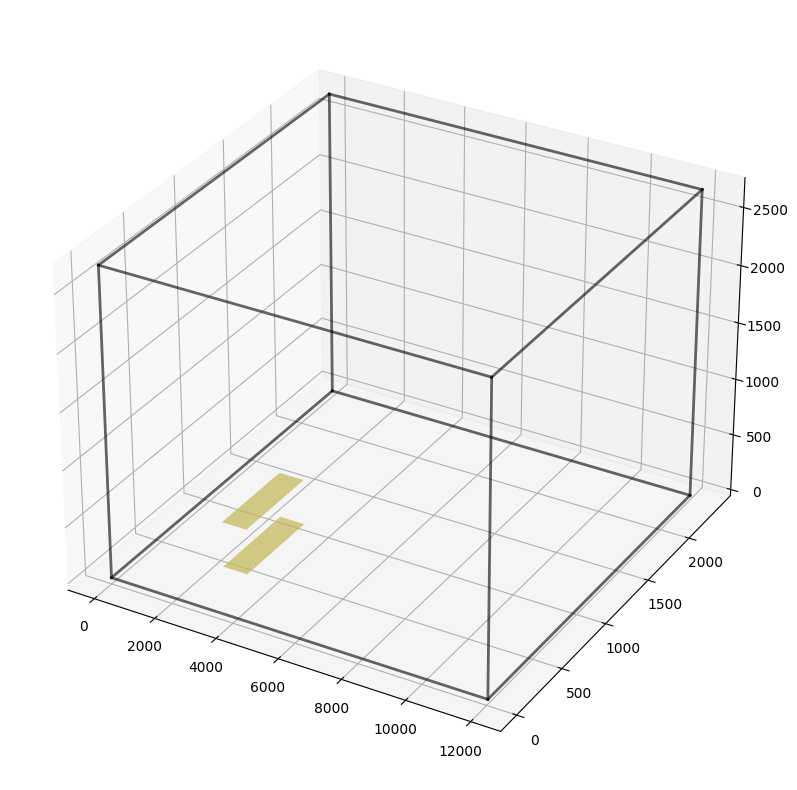

In [12]:

if __name__ == "__main__":
    # 运行测试
    print("选择运行模式:")
    print("1. 测试环境")
    print("2. 训练模型") 
    print("3. 工业级演示")
    
    #choice = input("请输入选择 (1/2/3): ").strip()
    choice = "3"    
    if choice == "1":
        test_environment()
    elif choice == "2":
        train_model()
    elif choice == "3":
        industrial_demo()
    else:
        print("运行环境测试...")
        test_environment()

In [13]:
import tensorflow as tf

# 时间复杂度与空间复杂度分析

** 时间复杂度
- **每轮训练**：
  - 动作选择：$O(A)$，其中 $A$ 是有效动作数。
  - 动作执行：与环境交互，复杂度取决于 `step()` 和 `can_place_box()` 的实现。
  - 经验回放：$O(B \cdot F)$，其中 $B$ 是批量大小，$F$ 是神经网络的前向传播复杂度。
- **总复杂度**：$O(E \cdot T \cdot (A + B \cdot F))$，其中：
  - $E$：训练轮数。
  - $T$：每轮的时间步数。

** 空间复杂度
- **经验缓冲区**：$O(M)$，其中 $M$ 是缓冲区的最大容量。
- **神经网络**：$O(P)$，其中 $P$ 是网络参数数量。
- **环境状态**：与高度图和箱子特征的存储需求相关。

通过以上分析，可以看出时间复杂度主要受有效动作数和神经网络训练的影响，而空间复杂度则与经验缓冲区和神经网络的规模密切相关。